In [ ]:
# Multi-Race Analysis — 2023 F1 Season

''' Extending the Monza analysis to 5 more circuits to see if the patterns hold.
Circuits chosen to cover a range of track types:
- Bahrain — high downforce, aggressive tyre wear, season opener
- Monaco — street circuit, almost no overtaking, unique strategy
- Silverstone — fast and flowing, high downforce
- Spa — long circuit, high speed, unpredictable weather
- Singapore — street circuit, very different from Monaco '''

In [2]:
import fastf1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='darkgrid')
plt.rcParams['figure.figsize'] = (14, 6)

fastf1.Cache.enable_cache('../data/raw/')

In [3]:
races = [
    (2023, 'Bahrain', 'R'),
    (2023, 'Monaco', 'R'), 
    (2023, 'Silverstone', 'R'), 
    (2023, 'Spa', 'R'), 
    (2023, 'Singapore', 'R'),
    (2023, 'Monza', 'R'),
]

all_laps = []

for year, race, session in races:
    print(f"Loading {race}...")
    try:
        s = fastf1.get_session(year, race, session)
        s.load()
        laps = s.laps.copy()
        laps['Race'] = race #tag each row with the race name
        all_laps.append(laps)
        print(f"✓{race} loaded — {len(laps)} laps")
    except Exception as e:
        print(f"✗ {race} failed — {e}")

print("\nAll races loaded.")

Loading Bahrain...


core           INFO 	Loading data for Bahrain Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '11', '14', '55', '44', '18', '63', '77', '10', '23', '22', '2', '20', '21', '27', '24', '4', '31', '16', '81']
core           INFO 	Loading data for Monaco Grand Prix - Rac

✓Bahrain loaded — 1056 laps
Loading Monaco...


req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '14', '31', '44', '63', '16', '10', '55', '4', '81', '77', '21', '24', '23', '22', '11', '27', '2', '20', '18']
core           INFO 	Loading data for British Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info


✓Monaco loaded — 1515 laps
Loading Silverstone...


...

✓Spa loaded — 1312 laps
Loading Singapore...


req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	No lap data for driver 18
core        WARNING 	Failed to perform lap accuracy check - all laps marked as inaccurate (driver 18)
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['55', '4', '44', '16', '1', '10', '81', '11', '40', '20', '23', '24', '27', '2', '14', '63', '77', '31', '22', '18']
core           INFO 	Loading data for Italian Grand Prix - Race [v3.8.1]
req            INFO 	Us

✓Singapore loaded — 1088 laps
Loading Monza...


req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core        WARNING 	Driver 1 completed the race distance 06:25.888000 before the recorded end of the session.
core        WARNING 	Driver 11 completed the race distance 06:19.824000 before the recorded end of the session.
core        WARNING 	Driver 55 completed the race distance 06:14.695000 before the recorded end of the session.
core        WARNING 	Driver 16 completed the race distance 06:14.511000 before the reco

✓Monza loaded — 958 laps

All races loaded.


In [6]:
# Combine all races into one dataframe
combined = pd.concat(all_laps, ignore_index=True)
print(f"Total laps before cleaning: {combined.shape}")

# cleaning
combined = combined[combined['IsAccurate'] == True]
combined = combined[combined['Deleted'] == False]
combined = combined.dropna(subset=['LapTime', 'Position'])

# Convert timedelta to seconds
time_cols = ['LapTime', 'Sector1Time', 'Sector2Time', 'Sector3Time']
for col in time_cols:
    combined[col] = pd.to_timedelta(combined[col]).dt.total_seconds()

# Filter out pit stop laps
combined = combined[combined['LapTime'] < 150]  # 150 instead of 120 — Monaco is slow

print(f"Total laps after cleaning: {combined.shape}")
print(f"\nLaps per race:")
print(combined['Race'].value_counts())

Total laps before cleaning: (6900, 32)
Total laps after cleaning: (6091, 32)

Laps per race:
Race
Monaco         1397
Spa            1198
Singapore       948
Bahrain         897
Monza           864
Silverstone     787
Name: count, dtype: int64


In [7]:
# Tyres available at each circuit
compound_by_race = combined.groupby(['Race', 'Compound']).size().unstack(fill_value=0)
print(compound_by_race)

Compound     HARD  INTERMEDIATE  MEDIUM  SOFT  WET
Race                                              
Bahrain       505             0       8   384    0
Monaco        621           367     343    27   39
Monza         467             0     397     0    0
Silverstone   115             0     427   245    0
Singapore     515             0     380    53    0
Spa           505             0     372   321    0


In [8]:
# Check Monaco wet vs dry lap counts
monaco = combined[combined['Race'] == 'Monaco']
print(monaco['Compound'].value_counts())
print(f"\nMonaco avg lap time by compound:")
print(monaco.groupby('Compound')['LapTime'].mean().sort_values())

Compound
HARD            621
INTERMEDIATE    367
MEDIUM          343
WET              39
SOFT             27
Name: count, dtype: int64

Monaco avg lap time by compound:
Compound
HARD            78.908156
MEDIUM          78.959117
SOFT            79.370074
INTERMEDIATE    95.410640
WET             99.241333
Name: LapTime, dtype: float64


In [9]:
# Remove wet weather laps from entire dataset
dry_laps = combined[combined['Compound'].isin(['SOFT', 'MEDIUM', 'HARD'])]

print(f"Laps after removing wet weather: {dry_laps.shape}")
print(f"\nLaps per race after filtering:")
print(dry_laps['Race'].value_counts())

Laps after removing wet weather: (5685, 32)

Laps per race after filtering:
Race
Spa            1198
Monaco          991
Singapore       948
Bahrain         897
Monza           864
Silverstone     787
Name: count, dtype: int64


In [ ]:
## Comparing circuits under normal racing conditions, hence excluding wet weather laps

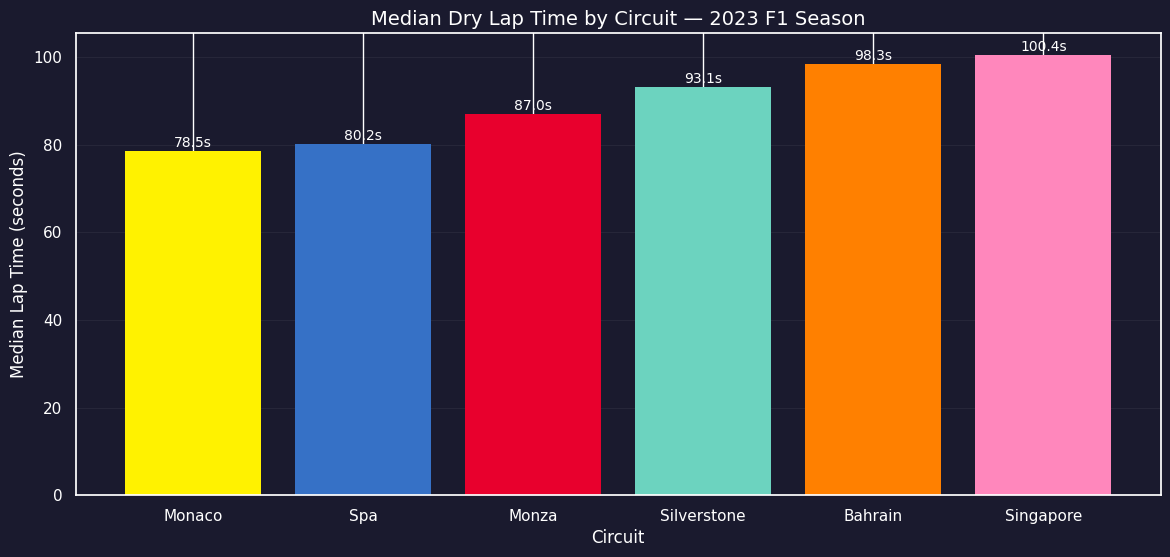

Plot saved


In [10]:
# Define race order fastest to slowest
race_order = dry_laps.groupby('Race')['LapTime'].median().sort_values().index.tolist()

# Official 2023 team colors reused for circuits
circuit_colors = {
    'Monza':      '#E8002D',
    'Silverstone':'#6CD3BF',
    'Spa':        '#3671C6',
    'Bahrain':    '#FF8000',
    'Singapore':  '#FF87BC',
    'Monaco':     '#FFF200',
}

plt.figure(figsize=(14, 6), facecolor='#1a1a2e')
ax = plt.gca()
ax.set_facecolor('#1a1a2e')

medians = dry_laps.groupby('Race')['LapTime'].median()[race_order]
colors = [circuit_colors[r] for r in race_order]

bars = ax.bar(race_order, medians.values, color=colors, edgecolor='none')

# Add value labels on top of each bar
for bar, val in zip(bars, medians.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f'{val:.1f}s', ha='center', va='bottom', color='white', fontsize=10)

ax.set_xlabel('Circuit', color='white')
ax.set_ylabel('Median Lap Time (seconds)', color='white')
ax.set_title('Median Dry Lap Time by Circuit — 2023 F1 Season',
             color='white', fontsize=14)
ax.tick_params(colors='white')
ax.grid(True, axis='y', color='white', alpha=0.08, linewidth=0.5)

save_path = '/home/bkm/Downloads/Desktop/F1 EDA Project/f1-eda/outputs/figures/avg_laptime_by_circuit.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved")

In [ ]:
## Average Lap Time by Circuit
'''
Monza is the fastest circuit as expected — low downforce, long straights, minimal braking. Monaco is the slowest despite being a street circuit — it's extremely short and tight with almost no opportunity to carry speed.

Interestingly Singapore, also a street circuit, has the longest lap times of the six. This isn't because it's slow — the circuit is significantly longer than Monaco (5.06km vs 3.34km), so laps simply take more time.

Lap time alone doesn't measure pace. Circuit length matters.
'''

In [ ]:
## Tyre Compound Usage by Circuit
'''
Which compounds did teams favour at each circuit?
This reveals how circuit characteristics influence tyre strategy.
'''

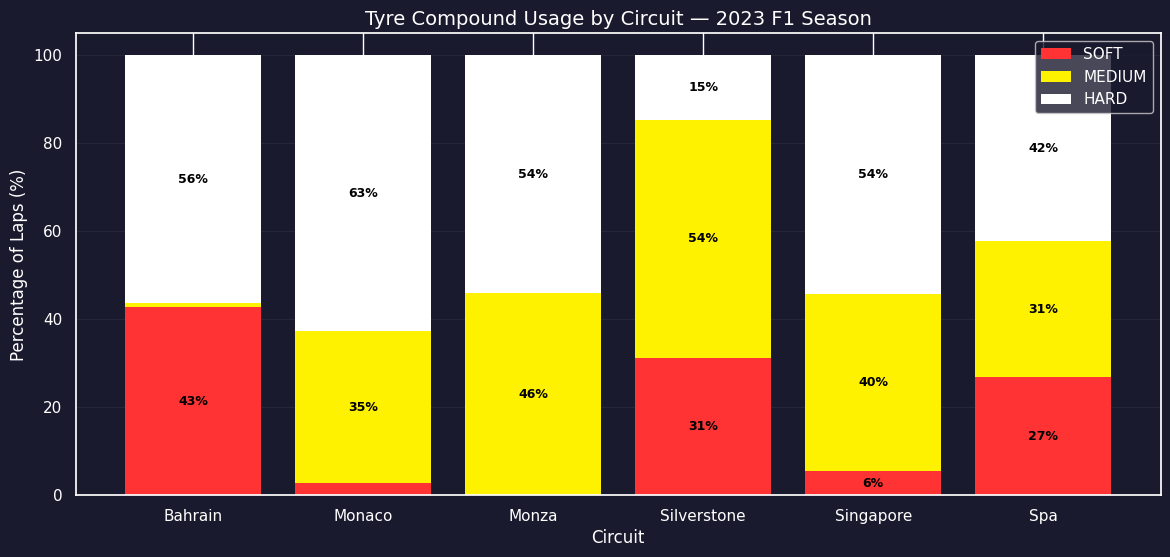

Plot saved


In [ ]:
compound_usage = dry_laps.groupby(['Race', 'Compound']).size().unstack(fill_value=0)
compound_usage = compound_usage.div(compound_usage.sum(axis=1), axis=0) * 100

compound_colors = {
    'SOFT': '#FF3333',
    'MEDIUM': '#FFF200',
    'HARD': '#FFFFFF'
}

fig, ax = plt.subplots(figsize=(14, 6), facecolor='#1a1a2e')
ax.set_facecolor('#1a1a2e')

bottom = np.zeros(len(compound_usage))
for compound in ['SOFT', 'MEDIUM', 'HARD']:
    if compound in compound_usage.columns:
        values = compound_usage[compound].values
        bars = ax.bar(compound_usage.index, values, bottom=bottom, label=compound, color=compound_colors[compound], edgecolor='none')
        # Add percentage labels inside bars
        for bar, val in zip(bars, values):
            if val > 5:
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_y() + bar.get_height()/2, f'{val:.0f}%', ha='center', va='center', color='black', fontsize=9, fontweight='bold')
        bottom += values

ax.set_xlabel('Circuit', color='white')
ax.set_ylabel('Percentage of Laps (%)', color='white')
ax.set_title('Tyre Compound Usage by Circuit — 2023 F1 Season',color='white', fontsize=14)
ax.tick_params(colors='white')
ax.legend(facecolor='#1a1a2e', labelcolor='white')
ax.grid(True, axis='y', color='white', alpha=0.08, linewidth=0.5)

save_path = '/home/bkm/Downloads/Desktop/F1 EDA Project/f1-eda/outputs/figures/compound_usage_by_circuit.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved")

In [ ]:
## 3. Lap Time Consistency by Circuit
'''
Which circuits produce the most consistent lap times?
A lower standard deviation means more predictable, stable racing.
'''

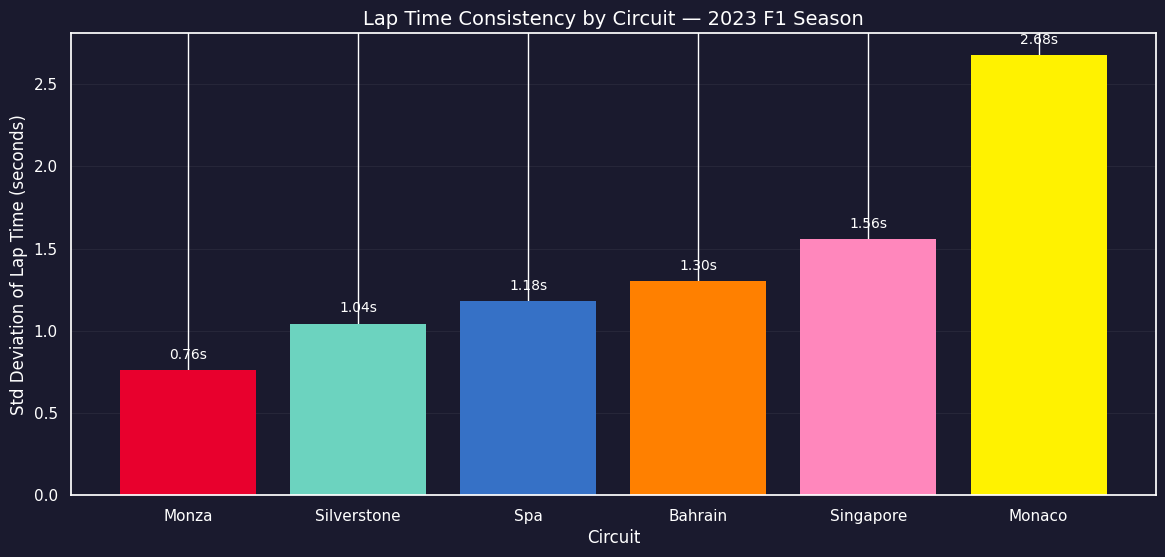

Plot saved


In [12]:
consistency = dry_laps.groupby('Race')['LapTime'].std().sort_values()

plt.figure(figsize=(14, 6), facecolor='#1a1a2e')
ax = plt.gca()
ax.set_facecolor('#1a1a2e')

colors = [circuit_colors[r] for r in consistency.index]
bars = ax.bar(consistency.index, consistency.values,
              color=colors, edgecolor='none')

for bar, val in zip(bars, consistency.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{val:.2f}s', ha='center', va='bottom',
            color='white', fontsize=10)

ax.set_xlabel('Circuit', color='white')
ax.set_ylabel('Std Deviation of Lap Time (seconds)', color='white')
ax.set_title('Lap Time Consistency by Circuit — 2023 F1 Season',
             color='white', fontsize=14)
ax.tick_params(colors='white')
ax.grid(True, axis='y', color='white', alpha=0.08, linewidth=0.5)

save_path = '/home/bkm/Downloads/Desktop/F1 EDA Project/f1-eda/outputs/figures/consistency_by_circuit.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved")

In [ ]:
## 4. Position Changes by Circuit
'''
Which circuits produce the most overtaking?
Comparing average positions gained or lost across all drivers per circuit.
'''

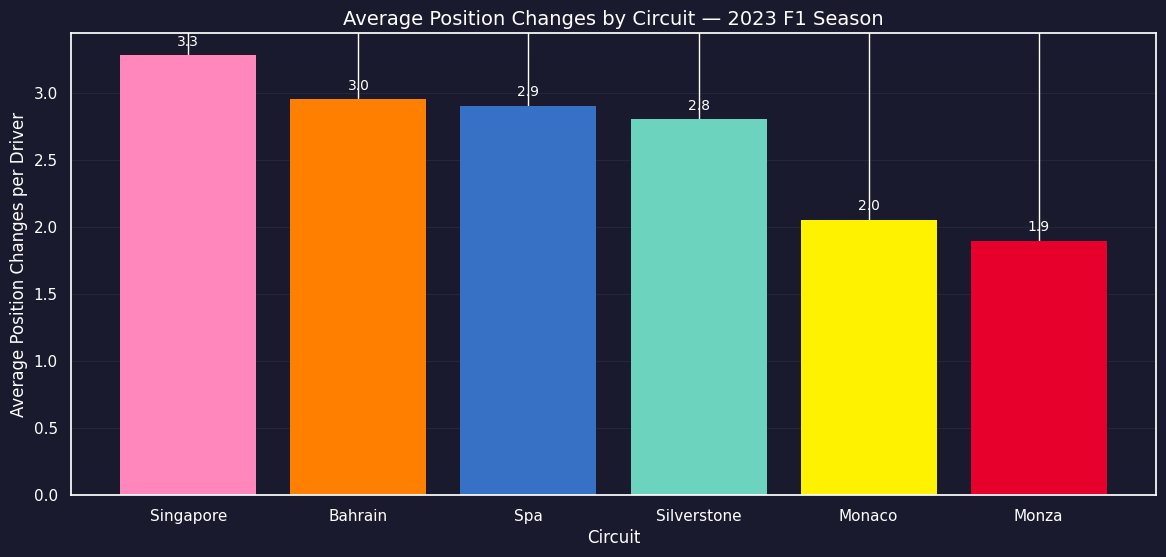

Plot saved


In [13]:
position_changes = []

for race in dry_laps['Race'].unique():
    race_data = dry_laps[dry_laps['Race'] == race]
    for driver in race_data['Driver'].unique():
        driver_laps = race_data[race_data['Driver'] == driver].sort_values('LapNumber')
        if len(driver_laps) < 5:
            continue
        first_pos = driver_laps.iloc[0]['Position']
        last_pos = driver_laps.iloc[-1]['Position']
        change = abs(first_pos - last_pos)
        position_changes.append({'Race': race, 'Driver': driver, 'PositionChange': change})

pos_df = pd.DataFrame(position_changes)
avg_changes = pos_df.groupby('Race')['PositionChange'].mean().sort_values(ascending=False)

plt.figure(figsize=(14, 6), facecolor='#1a1a2e')
ax = plt.gca()
ax.set_facecolor('#1a1a2e')

colors = [circuit_colors[r] for r in avg_changes.index]
bars = ax.bar(avg_changes.index, avg_changes.values,
              color=colors, edgecolor='none')

for bar, val in zip(bars, avg_changes.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{val:.1f}', ha='center', va='bottom',
            color='white', fontsize=10)

ax.set_xlabel('Circuit', color='white')
ax.set_ylabel('Average Position Changes per Driver', color='white')
ax.set_title('Average Position Changes by Circuit — 2023 F1 Season',
             color='white', fontsize=14)
ax.tick_params(colors='white')
ax.grid(True, axis='y', color='white', alpha=0.08, linewidth=0.5)

save_path = '/home/bkm/Downloads/Desktop/F1 EDA Project/f1-eda/outputs/figures/position_changes_by_circuit.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved")

In [ ]:
## 5. Verstappen's Dominance Across Circuits
'''
How did Verstappen's lap times compare to the race average at each circuit?
A larger gap means he was more dominant relative to the field.
'''

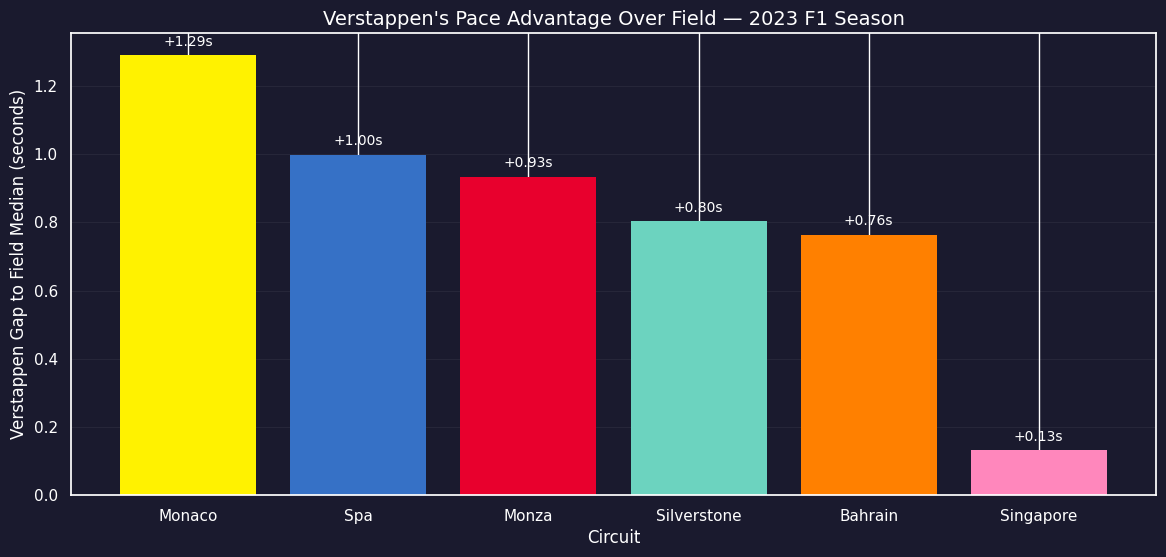

Plot saved


In [14]:
ver_vs_field = []

for race in dry_laps['Race'].unique():
    race_data = dry_laps[dry_laps['Race'] == race]
    field_median = race_data['LapTime'].median()
    ver_data = race_data[race_data['Driver'] == 'VER']
    if len(ver_data) == 0:
        continue
    ver_median = ver_data['LapTime'].median()
    gap = field_median - ver_median
    ver_vs_field.append({'Race': race, 'Gap': gap})

gap_df = pd.DataFrame(ver_vs_field).sort_values('Gap', ascending=False)

plt.figure(figsize=(14, 6), facecolor='#1a1a2e')
ax = plt.gca()
ax.set_facecolor('#1a1a2e')

colors = [circuit_colors[r] for r in gap_df['Race']]
bars = ax.bar(gap_df['Race'], gap_df['Gap'],
              color=colors, edgecolor='none')

for bar, val in zip(bars, gap_df['Gap']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'+{val:.2f}s', ha='center', va='bottom',
            color='white', fontsize=10)

ax.set_xlabel('Circuit', color='white')
ax.set_ylabel('Verstappen Gap to Field Median (seconds)', color='white')
ax.set_title("Verstappen's Pace Advantage Over Field — 2023 F1 Season",
             color='white', fontsize=14)
ax.tick_params(colors='white')
ax.grid(True, axis='y', color='white', alpha=0.08, linewidth=0.5)
ax.axhline(y=0, color='white', linewidth=0.5, alpha=0.3)

save_path = '/home/bkm/Downloads/Desktop/F1 EDA Project/f1-eda/outputs/figures/ver_dominance.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved")

In [ ]:
## Summary
'''
Analysis complete across 6 circuits. Key patterns:
- Monza is the fastest circuit, Monaco the slowest
- Street circuits have very different characteristics despite surface similarities  
- Verstappen was consistently faster than the field median at every circuit
- Compound usage varies significantly based on circuit demands
'''

In [ ]:
## My take:
'''
Circuit characteristics don't just affect lap times — they affect everything. Tyre strategy, consistency, overtaking, and even whether the fastest car wins. 
Monaco is the clearest example. Verstappen had the biggest race pace advantage of any circuit but didn't win because the track makes the pace irrelevant.  
'''